## 0. Environment Setup

In [ ]:
!pip install ultralytics

import os
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
import random

from collections import defaultdict
from ultralytics import YOLO
from ultralytics.data.converter import convert_coco

from google.colab import drive
drive.mount('/content/drive')

dataset_root = "/content/drive/MyDrive/Traffic State Optimization/traffic_dataset"
class_names = ["motorcycle", "bicycle", "bus", "car", "truck"]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


MessageError: Error: credential propagation was unsuccessful

## 1. Sanity Check and Verification

In [ ]:
train_img = os.path.join(dataset_root, "images/train")
train_lbl = os.path.join(dataset_root, "labels/train")

val_img = os.path.join(dataset_root, "images/val")
val_lbl = os.path.join(dataset_root, "labels/val")

print("Train images:", len(os.listdir(train_img)))
print("Train labels:", len(os.listdir(train_lbl)))

print("Val images:", len(os.listdir(val_img)))
print("Val labels:", len(os.listdir(val_lbl)))

Train images: 274
Train labels: 274
Val images: 68
Val labels: 68


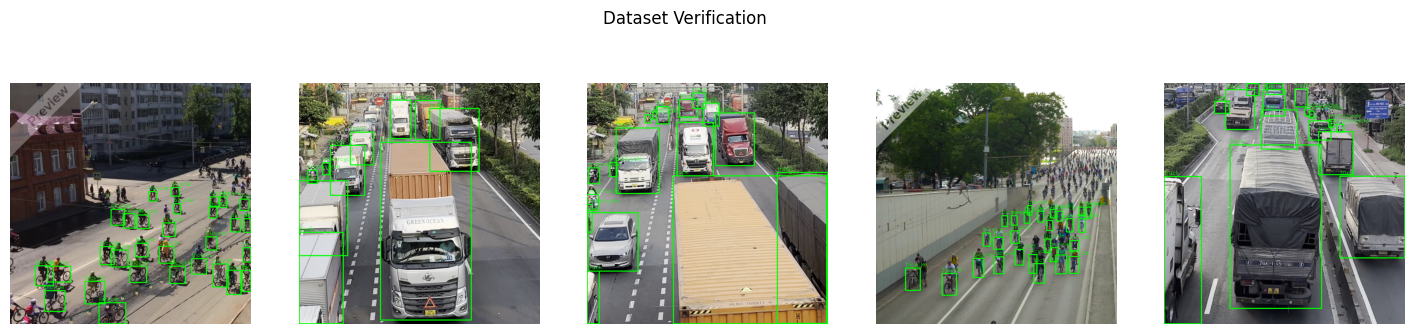

In [ ]:
sample_images = random.sample(os.listdir(train_img), 5)
plt.figure(figsize = (18, 4))

for i, img_name in enumerate(sample_images) :

    img_path = os.path.join(train_img, img_name)
    label_path = os.path.join(train_lbl, img_name.replace(".png", ".txt").replace(".jpg", ".txt"))
    img = cv2.imread(img_path)
    h, w = img.shape[ : 2]

    with open(label_path) as f :
        lines = f.readlines()

    for line in lines :

        cls, x, y, bw, bh = map(float, line.split())
        x_center = x * w
        y_center = y * h
        bw = bw * w
        bh = bh * h

        x1 = int(x_center - bw / 2)
        y1 = int(y_center - bh / 2)
        x2 = int(x_center + bw / 2)
        y2 = int(y_center + bh / 2)

        label = class_names[int(cls)]
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    plt.subplot(1, 5, i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.suptitle("Dataset Verification")
plt.show()

## 2. Finetune the model

In [ ]:
model = YOLO("yolov8m.pt")
model.train(
    data      = "/content/drive/MyDrive/Traffic State Optimization/traffic_dataset.yaml",
    epochs    = 80,
    imgsz     = 640,
    batch     = 8,
    device    = 0,
    workers   = 4,
    freeze    = 10,
    patience  = 20,
    plots     = True,
    project   = "/content/drive/MyDrive/Traffic State Optimization/runs",
    name      = "traffic_training"
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Traffic State Optimization/traffic_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=traffic_training, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bdaa8269ca0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

## 3. Compare with baseline

In [ ]:
test_dir = "/content/drive/MyDrive/Traffic State Optimization/Test"

# load models
baseline_model  = YOLO("yolov8m.pt")
finetuned_model = YOLO("/content/drive/MyDrive/Traffic State Optimization/runs/traffic_training/weights/best.pt")

# run inference
baseline_results = baseline_model.predict(
    source = test_dir,
    conf = 0.25,
    save = True,
    project = "/content/runs/detect",
    name = "baseline"
)

finetuned_results = finetuned_model.predict(
    source = test_dir,
    conf = 0.25,
    save = True,
    project = "/content/runs/detect",
    name = "finetuned"
)


image 1/10 /content/drive/MyDrive/Traffic State Optimization/Test/traffic_1.jpg: 448x640 16 persons, 8 cars, 22 motorcycles, 1 truck, 51.4ms
image 2/10 /content/drive/MyDrive/Traffic State Optimization/Test/traffic_10.jpg: 416x640 13 persons, 1 bicycle, 19 cars, 17 motorcycles, 3 trucks, 1 umbrella, 1 clock, 60.3ms
image 3/10 /content/drive/MyDrive/Traffic State Optimization/Test/traffic_2.jpg: 448x640 8 persons, 14 cars, 3 motorcycles, 6 buss, 28.1ms
image 4/10 /content/drive/MyDrive/Traffic State Optimization/Test/traffic_3.jpg: 416x640 15 persons, 7 motorcycles, 1 stop sign, 28.0ms
image 5/10 /content/drive/MyDrive/Traffic State Optimization/Test/traffic_4.jpg: 416x640 1 person, 5 traffic lights, 26.9ms
image 6/10 /content/drive/MyDrive/Traffic State Optimization/Test/traffic_5.jpg: 416x640 3 persons, 10 cars, 6 motorcycles, 1 bus, 1 traffic light, 26.9ms
image 7/10 /content/drive/MyDrive/Traffic State Optimization/Test/traffic_6.jpg: 448x640 19 persons, 12 motorcycles, 1 truck, 28

In [ ]:
def compare_predictions(original_dir, baseline_dir, finetuned_dir, start = 0, num_images = 5) :

    images = sorted(os.listdir(original_dir))[start : start+num_images]

    plt.figure(figsize = (15, 3 * num_images))

    for i, img in enumerate(images) :

        orig_img = cv2.imread(os.path.join(original_dir,  img))
        base_img = cv2.imread(os.path.join(baseline_dir,  img))
        fine_img = cv2.imread(os.path.join(finetuned_dir, img))

        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
        base_img = cv2.cvtColor(base_img, cv2.COLOR_BGR2RGB)
        fine_img = cv2.cvtColor(fine_img, cv2.COLOR_BGR2RGB)

        # original
        plt.subplot(num_images, 3, 3 * i + 1)
        plt.imshow(orig_img)
        plt.title("Original")
        plt.axis("off")

        # baseline
        plt.subplot(num_images, 3, 3 * i + 2)
        plt.imshow(base_img)
        plt.title("Baseline")
        plt.axis("off")

        # finetuned
        plt.subplot(num_images, 3, 3 * i + 3)
        plt.imshow(fine_img)
        plt.title("Finetuned")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

original_dir  = "/content/drive/MyDrive/Traffic State Optimization/Test"
baseline_dir  = "/content/runs/detect/baseline"
finetuned_dir = "/content/runs/detect/finetuned"

compare_predictions(original_dir, baseline_dir, finetuned_dir, start = 0, num_images = 5)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
compare_predictions(original_dir, baseline_dir, finetuned_dir, start = 5, num_images = 5)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Extract detections from YOLO results

def get_detections(results, model) :

    detections = []

    for r in results :

        boxes = r.boxes.xyxy.cpu().numpy()
        classes = r.boxes.cls.cpu().numpy()
        scores = r.boxes.conf.cpu().numpy()
        img_dets = []

        for box, cls, score in zip(boxes, classes, scores) :

            label = model.names[int(cls)]

            if label not in class_names :
                continue

            img_dets.append((label, box, score))

        detections.append(img_dets)

    return detections


# Compute comparison groups
def iou(boxA, boxB) :

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB - xA) * max(0, yB - yA)

    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    return inter / (areaA + areaB - inter + 1e-6)


# Categorize detections
def categorize_detections(base_dets, fine_dets, iou_thresh = 0.5) :

    baseline_only = []
    finetuned_only = []
    both = []
    matched = set()

    for i, (lbl1, box1, _) in enumerate(base_dets) :

        found = False

        for j, (lbl2, box2, _) in enumerate(fine_dets) :

            if j in matched :
                continue

            if lbl1 == lbl2 and iou(box1, box2) > iou_thresh :

                both.append((lbl1, box1))
                matched.add(j)
                found = True
                break

        if not found :
            baseline_only.append((lbl1, box1))

    for j, (lbl2, box2, _) in enumerate(fine_dets) :
        if j not in matched :
            finetuned_only.append((lbl2, box2))

    return baseline_only, finetuned_only, both


def visualize_comparison(img_path, base_dets, fine_dets) :

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    base_only, fine_only, both = categorize_detections(base_dets, fine_dets)

    for lbl, box in base_only :
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    for lbl, box in fine_only :
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)

    for lbl, box in both :
        x1,y1,x2,y2 = map(int,box)
        cv2.rectangle(img, (x1, y1), (x2, y2),(0, 255, 0), 2)

    plt.figure(figsize = (12, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Green = both | Red = baseline only | Blue = finetuned only")
    plt.show()

In [ ]:
base_detections = get_detections(baseline_results, baseline_model)
fine_detections = get_detections(finetuned_results, finetuned_model)

images = sorted(os.listdir(test_dir))

for i,img in enumerate(images) :
    img_path = os.path.join(test_dir,img)
    visualize_comparison(img_path, base_detections[i], fine_detections[i])

Output hidden; open in https://colab.research.google.com to view.